# Movement of banks in and out of size quintiles, 2017–2026

Companion to `size_quintile_distributions.ipynb`. That notebook assigns each bank to a size quintile every quarter from its total assets at *t*−1 and re-assigns the groups every quarter. This notebook asks how much group membership actually changes, with a focus on 2017Q1–2026Q2:

- **How often do banks change quintile** from one quarter to the next, and is it mostly up or down?
- **Where do banks go:** transition matrices over one quarter, four quarters, and the full 2017Q1 → 2026Q2 span, including banks that exit (stop filing) and banks that enter.
- **How persistent is membership** for the cohort of banks in each quintile in 2017Q1?
- **Why do banks cross a boundary:** their own asset change, or the cutoffs moving past them? And how many crossings reverse within a year?

**Definitions.** Each quarter, every filing bank is ranked by that quarter's total assets and split into five equal groups (Q1 smallest, Q5 largest). A bank's quintile at *t*−1 is exactly the group the distributions notebook assigns it in quarter *t*, so a quintile change here is a change in group assignment there. An **exit** is a bank that files at *t*−1 but not at *t* (merger, failure, charter change or voluntary liquidation; the panel does not record which). An **entrant** files at *t* but not at *t*−1. Same sample rules as the other notebooks: insured U.S. branches of foreign banks (class `OI`) are dropped.

**Outputs** go to `output/figures/quintile_transitions/` (PDF, PNG, and a caption-ready `_bare.pdf`) and `output/tables/quintile_transition_matrix.*`, `output/tables/quintile_mobility_by_year.*`.

In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FuncFormatter, MultipleLocator, PercentFormatter

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED = ROOT / "data" / "processed"
FIGS = ROOT / "output" / "figures" / "quintile_transitions"
TABLES = ROOT / "output" / "tables"
FIGS.mkdir(parents=True, exist_ok=True)
TABLES.mkdir(parents=True, exist_ok=True)

## Figure style

Same style as the other notebooks. Size quintiles take the light-to-dark blue ramp (Q1 lightest). Movement outcomes use fixed categorical hues: blue for staying in the same quintile, aqua for moving up, orange for moving down, and gray for exiting. Transition matrices use a single-hue blue scale.

In [2]:
INK = "#1a1a1a"
MUTED = "#6b6b6b"
GRID = "#e3e3e3"
SHADE = "#e6e6e6"
QUINTILE_COLORS = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#104281"]
STATUS_COLORS = {"Same quintile": "#2a78d6", "Moved up": "#1baf7a", "Moved down": "#eb6834", "Exited": "#a3a3a3"}
MATRIX_CMAP = LinearSegmentedColormap.from_list("blues", ["#ffffff", "#cde2fb", "#86b6ef", "#2a78d6", "#104281"])

WIDTH, HEIGHT = 6.5, 2.9

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "STIXGeneral", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "text.color": INK,
    "axes.labelcolor": INK,
    "axes.edgecolor": INK,
    "axes.linewidth": 0.6,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.grid.axis": "y",
    "grid.color": GRID,
    "grid.linewidth": 0.6,
    "xtick.color": INK,
    "ytick.color": INK,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.minor.width": 0.4,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "lines.linewidth": 1.4,
    "legend.frameon": False,
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.03,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

## Recession dates and shared helpers

In [3]:
NBER_CYCLES = [("1990-07", "1991-03"), ("2001-03", "2001-11"), ("2007-12", "2009-06"), ("2020-02", "2020-04")]
RECESSIONS = [((pd.Period(peak, "M") + 1).start_time, pd.Period(trough, "M").end_time)
              for peak, trough in NBER_CYCLES]
X_RANGE = (pd.Timestamp("1992-01-01"), pd.Timestamp("2026-09-30"))
START, END = pd.Timestamp("2017-03-31"), pd.Timestamp("2026-06-30")  # focus window (quarter t of each transition)
WINDOW_RANGE = (pd.Timestamp("2016-10-01"), pd.Timestamp("2026-09-30"))


def shade_recessions(ax):
    for start, end in RECESSIONS:
        ax.axvspan(start, end, color=SHADE, lw=0, zorder=0)


def format_time_axis(ax, xlim=X_RANGE, years_between_ticks=4):
    ax.set_xlim(*xlim)
    ax.xaxis.set_major_locator(mdates.YearLocator(years_between_ticks, month=1, day=1))
    ax.xaxis.set_minor_locator(mdates.YearLocator(1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(axis="x", which="minor", length=2)
    ax.grid(False, axis="x")


def add_note(fig, text):
    fig.text(0.0, -0.02, text, ha="left", va="top", fontsize=8, color=MUTED, wrap=True, gid="note")


def save(fig, name):
    for ext in ("pdf", "png"):
        fig.savefig(FIGS / f"{name}.{ext}")
    # Caption-ready copy for LaTeX: no in-figure title or note
    extras = [t for t in [*fig.texts, fig._suptitle] if t is not None and t.get_gid() in ("note", "title")]
    for t in extras:
        t.set_visible(False)
    fig.savefig(FIGS / f"{name}_bare.pdf")
    for t in extras:
        t.set_visible(True)
    print(f"saved output/figures/quintile_transitions/{name}.pdf, .png and _bare.pdf")


pct0 = PercentFormatter(1, decimals=0)
SOURCE = "\nSource: FDIC Statistics on Depository Institutions; author's calculations."
QUINTILES = [1, 2, 3, 4, 5]
Q_LABELS = {1: "Q1 (smallest 20%)", 2: "Q2", 3: "Q3", 4: "Q4", 5: "Q5 (largest 20%)"}
qlabel = lambda d: f"{d.year}Q{d.quarter}"

## Load the panel and assign quintiles

Only identifiers and total assets are needed. Quintiles are formed within each quarter among all filing banks.

In [4]:
panel = pd.read_csv(PROCESSED / "bank_quarter_panel.csv", usecols=["CERT", "REPDTE", "BKCLASS", "ASSET"])
panel = panel.loc[(panel["BKCLASS"] != "OI") & (panel["ASSET"] > 0)].drop(columns="BKCLASS")
panel["date"] = pd.to_datetime(panel["REPDTE"].astype(str), format="%Y%m%d")
panel = panel.drop(columns="REPDTE")
assert not panel.duplicated(["CERT", "date"]).any()

size_pct = panel.groupby("date")["ASSET"].rank(pct=True, method="first")
panel["quintile"] = np.ceil(size_pct * 5).clip(1, 5).astype(int)

DATES = pd.DatetimeIndex(np.sort(panel["date"].unique()))
n_banks = panel.groupby("date").size()
print(f"{len(panel):,} bank-quarters, {panel['CERT'].nunique():,} banks, {qlabel(DATES[0])} to {qlabel(DATES[-1])}")
print(f"banks filing: {n_banks[pd.Timestamp('2016-12-31')]:,} in 2016Q4, {n_banks[END]:,} in {qlabel(END)}")

# Banks that skip a quarter and later reappear would be miscounted as an exit plus an entry
qidx = pd.Series(np.arange(len(DATES)), index=DATES)
span = panel.groupby("CERT")["date"].agg(["min", "max", "size"])
gaps = (qidx[span["max"]].to_numpy() - qidx[span["min"]].to_numpy() + 1) != span["size"].to_numpy()
print(f"banks with a gap in their filing history: {gaps.sum():,} of {len(span):,}")

1,127,856 bank-quarters, 17,121 banks, 1992Q1 to 2026Q2
banks filing: 5,913 in 2016Q4, 4,238 in 2026Q2
banks with a gap in their filing history: 12 of 17,121


## Transitions over *k* quarters

`transitions(k)` follows every bank filing at *t*−*k* to quarter *t* and records its quintile at both dates, or that it exited. Each row is one bank at one origin date.

In [5]:
STATUSES = ["Same quintile", "Moved up", "Moved down", "Exited"]
cur = panel[["CERT", "date", "quintile", "ASSET"]]


def transitions(k):
    orig = cur.rename(columns={"quintile": "q_from", "ASSET": "asset_from"})
    orig = orig.assign(date=orig["date"] + pd.offsets.QuarterEnd(k)).loc[lambda d: d["date"] <= DATES[-1]]
    out = orig.merge(cur.rename(columns={"quintile": "q_to", "ASSET": "asset_to"}), on=["CERT", "date"], how="left")
    out["status"] = np.select([out["q_to"].isna(), out["q_to"] > out["q_from"], out["q_to"] < out["q_from"]],
                              ["Exited", "Moved up", "Moved down"], "Same quintile")
    return out


moves = transitions(1)
in_window = moves["date"].between(START, END)
mw = moves.loc[in_window]

entrants = cur.merge(moves[["CERT", "date"]], on=["CERT", "date"], how="left", indicator=True)
entrants = entrants.loc[(entrants["_merge"] == "left_only") & (entrants["date"] > DATES[0])].drop(columns="_merge")

print(f"{qlabel(START)}–{qlabel(END)}: {len(mw):,} bank-quarter transitions over {mw['date'].nunique()} quarters")
display((mw["status"].value_counts(normalize=True).reindex(STATUSES) * 100).round(2).rename("% of bank-quarters").to_frame())

2017Q1–2026Q2: 189,519 bank-quarter transitions over 38 quarters


,% of bank-quarters
status,
Same quintile,95.99
Moved up,1.53
Moved down,1.56
Exited,0.93


In [6]:
# Per-bank view of the window: how many banks ever change quintile?
changers = mw.loc[mw["status"].isin(["Moved up", "Moved down"])]
per_bank = mw.groupby("CERT")["status"].agg(lambda s: s.isin(["Moved up", "Moved down"]).sum())
cohort = cur.loc[cur["date"] == START - pd.offsets.QuarterEnd(1), "CERT"]  # banks filing in 2016Q4
print(f"banks observed at some point in the window: {mw['CERT'].nunique():,}")
print(f"  changed quintile at least once:            {(per_bank > 0).sum():,} ({(per_bank > 0).mean():.1%})")
print(f"  changed quintile 3 or more times:          {(per_bank >= 3).sum():,} ({(per_bank >= 3).mean():.1%})")
print(f"quintile changes: {len(changers):,}; of which jumps of 2+ quintiles: "
      f"{((changers['q_to'] - changers['q_from']).abs() >= 2).sum():,}")
print(f"exits in window: {(mw['status'] == 'Exited').sum():,}; entrants in window: "
      f"{entrants['date'].between(START, END).sum():,}")

banks observed at some point in the window: 5,991
  changed quintile at least once:            2,140 (35.7%)
  changed quintile 3 or more times:          887 (14.8%)
quintile changes: 5,848; of which jumps of 2+ quintiles: 28
exits in window: 1,757; entrants in window: 82


## How often do banks change quintile?

Share of banks filing at *t*−1 that are in a higher quintile, a lower quintile, or no longer filing at *t*. The full sample is shown for context, with the 2017–2026 window marked.

saved output/figures/quintile_transitions/transition_rates_full_sample.pdf, .png and _bare.pdf


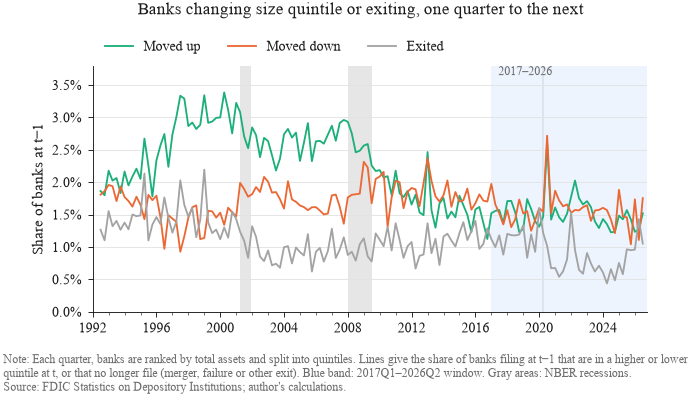

Average quarterly rates (%):


,1992–2016,2017–2026
status,,
Same quintile,94.79,96.00
Moved up,2.33,1.52
Moved down,1.72,1.56
Exited,1.16,0.92


In [7]:
shares = (moves.groupby("date")["status"].value_counts(normalize=True).unstack().reindex(columns=STATUSES).fillna(0))

fig, ax = plt.subplots(figsize=(WIDTH, HEIGHT))
shade_recessions(ax)
ax.axvspan(START - pd.offsets.QuarterEnd(1), X_RANGE[1], color="#cde2fb", alpha=0.35, lw=0, zorder=0)
for s in STATUSES[1:]:
    ax.plot(shares.index, shares[s], color=STATUS_COLORS[s], lw=1.2, label=s)
ax.set_ylim(0, shares[STATUSES[1:]].to_numpy().max() * 1.12)
ax.text(START, ax.get_ylim()[1], " 2017–2026", va="top", fontsize=8, color=MUTED)
ax.yaxis.set_major_formatter(PercentFormatter(1, decimals=1))
ax.set_ylabel("Share of banks at t\u22121")
format_time_axis(ax)
ax.legend(loc="lower left", bbox_to_anchor=(0, 1.0), ncols=3)
fig.suptitle("Banks changing size quintile or exiting, one quarter to the next", fontsize=11, y=1.08, gid="title")
add_note(fig, "Note: Each quarter, banks are ranked by total assets and split into quintiles. Lines give the share of "
              "banks filing at t\u22121 that are in a higher or lower quintile at t, or that no longer file (merger, "
              "failure or other exit). Blue band: 2017Q1\u20132026Q2 window. Gray areas: NBER recessions." + SOURCE)
save(fig, "transition_rates_full_sample")
plt.show()

print("Average quarterly rates (%):")
display(pd.DataFrame({"1992–2016": shares.loc[:START - pd.Timedelta(days=1)].mean(),
                      "2017–2026": shares.loc[START:END].mean()}).mul(100).round(2))

### By origin quintile, 2017–2026

Q1 banks cannot move down and Q5 banks cannot move up, so each has one boundary and the middle quintiles have two. Rates are therefore not directly comparable between the end and middle groups. Quarterly rates are noisy at the quintile level, so the lines are smoothed with a centered four-quarter moving average; the table below gives the unsmoothed averages.

saved output/figures/quintile_transitions/transition_rates_by_quintile.pdf, .png and _bare.pdf


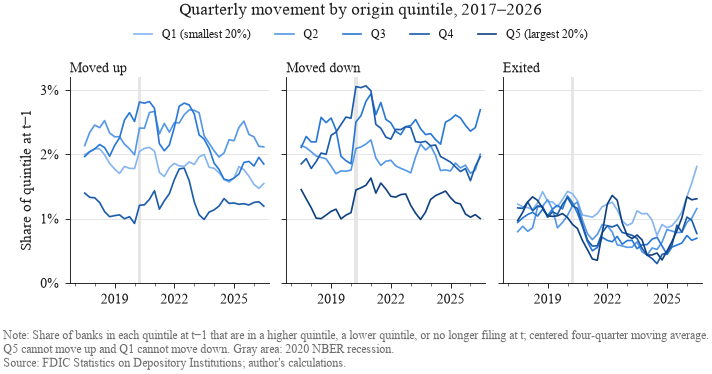

status,Same quintile,Moved up,Moved down,Exited
q_from,,,,
Q1 (smallest 20%),97.00,1.84,NaN,1.16
Q2,94.89,2.34,1.92,0.85
Q3,94.56,2.21,2.41,0.82
Q4,95.65,1.25,2.22,0.89
Q5 (largest 20%),97.85,NaN,1.25,0.91


In [8]:
by_q = (mw.groupby(["date", "q_from"])["status"].value_counts(normalize=True)
          .unstack().reindex(columns=STATUSES).fillna(0))

fig, axes = plt.subplots(1, 3, figsize=(WIDTH, 2.8), sharey=True)
for ax, s in zip(axes, STATUSES[1:]):
    shade_recessions(ax)
    for qi, color in zip(QUINTILES, QUINTILE_COLORS):
        if (s, qi) in [("Moved up", 5), ("Moved down", 1)]:
            continue
        y = by_q.xs(qi, level="q_from")[s].rolling(4, center=True, min_periods=3).mean()
        ax.plot(y.index, y, color=color, lw=1.1, label=Q_LABELS[qi])
    ax.set_title(s, loc="left", fontsize=9, pad=3)
    format_time_axis(ax, WINDOW_RANGE, years_between_ticks=3)
    ax.yaxis.set_major_formatter(PercentFormatter(1, decimals=0))
axes[0].set_ylabel("Share of quintile at t\u22121")
axes[0].set_ylim(0, None)
axes[0].yaxis.set_major_locator(MultipleLocator(0.01))
handles, labels = axes[2].get_legend_handles_labels()
fig.tight_layout(w_pad=0.8, rect=(0, 0, 1, 0.9))
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, 0.88), ncols=5, fontsize=8, handlelength=1.5)
fig.suptitle("Quarterly movement by origin quintile, 2017\u20132026", fontsize=11, y=1.04, gid="title")
add_note(fig, "Note: Share of banks in each quintile at t\u22121 that are in a higher quintile, a lower quintile, "
              "or no longer filing at t; centered four-quarter moving average. Q5 cannot move up and Q1 cannot "
              "move down. Gray area: 2020 NBER recession."
              + SOURCE)
save(fig, "transition_rates_by_quintile")
plt.show()

display((mw.groupby("q_from")["status"].value_counts(normalize=True).unstack()
           .reindex(columns=STATUSES).mul(100).round(2).rename(index=Q_LABELS)))

## Transition matrices

Rows are the quintile at the start, columns the quintile at the end (or exit); each row sums to 100%. The one- and four-quarter matrices pool every origin quarter whose end quarter falls in 2017Q1–2026Q2.

saved output/figures/quintile_transitions/transition_matrices.pdf, .png and _bare.pdf


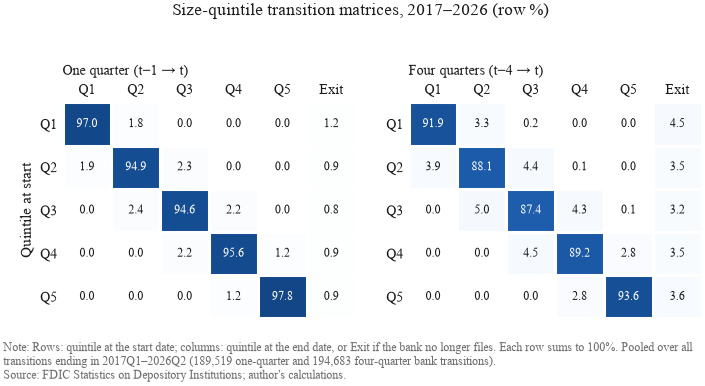

In [9]:
COLS = [1, 2, 3, 4, 5, "Exit"]


def matrix(df, row="q_from", col="q_to"):
    to = df[col].astype("Int64").astype(object).where(df[col].notna(), "Exit")
    counts = pd.crosstab(df[row], to).reindex(columns=COLS, fill_value=0)
    return counts, counts.div(counts.sum(axis=1), axis=0)


def draw_matrix(ax, share, counts=None, row_labels=None, col_labels=None, fontsize=8):
    vals = share.to_numpy(dtype=float)
    ax.imshow(vals, cmap=MATRIX_CMAP, vmin=0, vmax=1, aspect="auto")
    for i in range(vals.shape[0]):
        for j in range(vals.shape[1]):
            txt = f"{vals[i, j] * 100:.1f}" if vals[i, j] < 0.995 else f"{vals[i, j] * 100:.0f}"
            if counts is not None:
                txt += f"\n({counts.iat[i, j]:,})"
            ax.text(j, i, txt, ha="center", va="center", fontsize=fontsize,
                    color="white" if vals[i, j] > 0.55 else INK)
    ax.set_xticks(range(vals.shape[1]), col_labels or [f"Q{c}" if c != "Exit" else "Exit" for c in share.columns])
    ax.set_yticks(range(vals.shape[0]), row_labels or [f"Q{r}" for r in share.index])
    ax.tick_params(length=0)
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks(np.arange(-0.5, vals.shape[1]), minor=True)
    ax.set_yticks(np.arange(-0.5, vals.shape[0]), minor=True)
    ax.grid(True, which="minor", color="white", lw=2)
    ax.tick_params(which="minor", length=0)
    ax.xaxis.set_ticks_position("top")


c1, m1 = matrix(mw)
moves4 = transitions(4)
mw4 = moves4.loc[moves4["date"].between(START, END)]
c4, m4 = matrix(mw4)

fig, axes = plt.subplots(1, 2, figsize=(WIDTH, 2.9))
for ax, share, title in [(axes[0], m1, "One quarter (t\u22121 \u2192 t)"), (axes[1], m4, "Four quarters (t\u22124 \u2192 t)")]:
    draw_matrix(ax, share)
    ax.set_title(title, loc="left", fontsize=9, pad=18)
axes[0].set_ylabel("Quintile at start")
fig.suptitle("Size-quintile transition matrices, 2017\u20132026 (row %)", fontsize=11, y=1.04, gid="title")
fig.tight_layout(w_pad=2.0)
add_note(fig, "Note: Rows: quintile at the start date; columns: quintile at the end date, or Exit if the bank no "
              "longer files. Each row sums to 100%. Pooled over all transitions ending in 2017Q1\u20132026Q2 "
              f"({len(mw):,} one-quarter and {len(mw4):,} four-quarter bank transitions)." + SOURCE)
save(fig, "transition_matrices")
plt.show()

### 2017Q1 to 2026Q2: where did banks end up, and where did 2026 banks come from?

The long-horizon matrix follows every bank filing in 2017Q1 to 2026Q2. The extra row counts banks filing in 2026Q2 that did not file in 2017Q1 (new charters, plus any bank with a gap), so the columns show the origin of the 2026Q2 quintiles.

saved output/figures/quintile_transitions/transition_matrix_2017_2026.pdf, .png and _bare.pdf


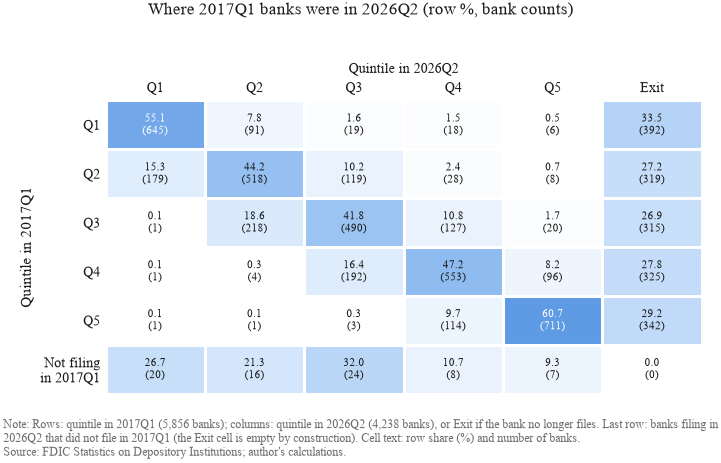

2017Q1 banks still filing in 2026Q2: 4,163 of 5,856 (71.1%)
among survivors, same quintile in both dates: 70.1%
  moved down: 17.2%, moved up: 12.8%


In [10]:
first = cur.loc[cur["date"] == START, ["CERT", "quintile"]].rename(columns={"quintile": "q_from"})
last = cur.loc[cur["date"] == END, ["CERT", "quintile"]].rename(columns={"quintile": "q_to"})
span_df = first.merge(last, on="CERT", how="outer")
span_df["q_from"] = span_df["q_from"].astype(object).where(span_df["q_from"].notna(), "New")
span_counts, span_share = matrix(span_df)
span_counts = span_counts.reindex(index=[1, 2, 3, 4, 5, "New"])
span_share = span_counts.div(span_counts.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(WIDTH, 3.6))
draw_matrix(ax, span_share, counts=span_counts, fontsize=7.5,
            row_labels=[f"Q{r}" for r in QUINTILES] + ["Not filing\nin 2017Q1"])
ax.set_ylabel("Quintile in 2017Q1")
ax.set_title("Quintile in 2026Q2", fontsize=9, pad=18)
fig.suptitle("Where 2017Q1 banks were in 2026Q2 (row %, bank counts)", fontsize=11, y=1.03, gid="title")
fig.tight_layout()
add_note(fig, f"Note: Rows: quintile in 2017Q1 ({len(first):,} banks); columns: quintile in 2026Q2 ({len(last):,} "
              "banks), or Exit if the bank no longer files. Last row: banks filing in 2026Q2 that did not file in "
              "2017Q1 (the Exit cell is empty by construction). Cell text: row share (%) and number of banks." + SOURCE)
save(fig, "transition_matrix_2017_2026")
plt.show()

survivors = span_df.loc[(span_df["q_from"] != "New") & span_df["q_to"].notna()]
print(f"2017Q1 banks still filing in 2026Q2: {len(survivors):,} of {len(first):,} ({len(survivors) / len(first):.1%})")
print(f"among survivors, same quintile in both dates: {(survivors['q_from'] == survivors['q_to']).mean():.1%}")
print(f"  moved down: {(survivors['q_to'] < survivors['q_from']).mean():.1%}, "
      f"moved up: {(survivors['q_to'] > survivors['q_from']).mean():.1%}")

## Persistence of the 2017Q1 cohort

For the banks in each quintile in 2017Q1, the share that at each later quarter is still in the same quintile, has moved up, has moved down, or has exited. Exit is absorbing; the other states can change back and forth.

saved output/figures/quintile_transitions/cohort_persistence_2017.pdf, .png and _bare.pdf


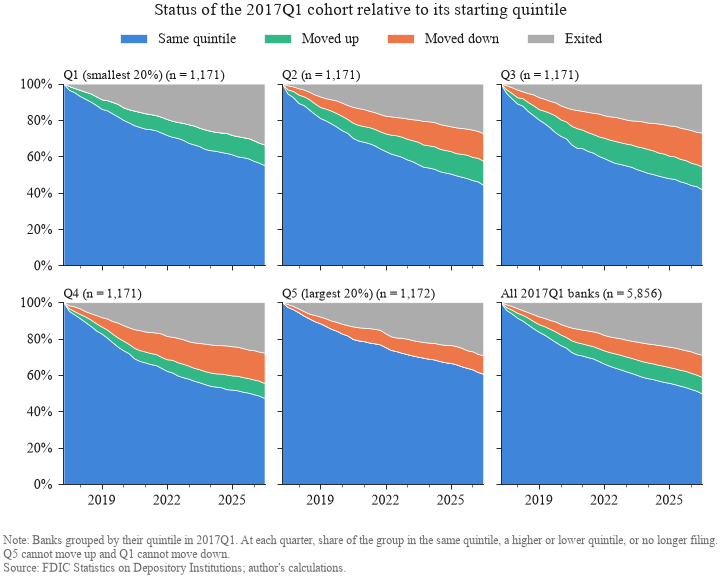

Status in 2026Q2 (%):


,Same quintile,Moved up,Moved down,Exited
Q1 (smallest 20%),55.1,11.4,0.0,33.5
Q2,44.2,13.2,15.3,27.2
Q3,41.8,12.6,18.7,26.9
Q4,47.2,8.2,16.8,27.8
Q5 (largest 20%),60.7,0.0,10.2,29.2
All 2017Q1 banks,49.8,9.1,12.2,28.9


In [11]:
wide = cur.loc[cur["date"].between(START, END)].pivot(index="CERT", columns="date", values="quintile")
wide = wide.loc[wide.index.isin(first["CERT"])]
q0 = wide[START]
last_seen = wide.apply(lambda r: r.last_valid_index(), axis=1)


def cohort_status(rows):
    w, start = wide.loc[rows], q0.loc[rows]
    out = {}
    for d in w.columns:
        now = w[d]
        exited = now.isna() & (last_seen.loc[rows] < d)
        out[d] = {"Same quintile": (now == start).mean(), "Moved up": (now > start).mean(),
                  "Moved down": (now < start).mean(), "Exited": exited.mean()}
    return pd.DataFrame(out).T


groups = [(Q_LABELS[qi], q0.index[q0 == qi]) for qi in QUINTILES] + [("All 2017Q1 banks", q0.index)]
fig, axes = plt.subplots(2, 3, figsize=(WIDTH, 4.6), sharex=True, sharey=True)
for ax, (title, rows) in zip(axes.flat, groups):
    st = cohort_status(rows)
    ax.stackplot(st.index, [st[s] for s in STATUSES], colors=[STATUS_COLORS[s] for s in STATUSES],
                 labels=STATUSES, edgecolor="white", linewidth=0.5, alpha=0.9)
    ax.set_title(f"{title} (n = {len(rows):,})", loc="left", fontsize=8.5, pad=3)
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(pct0)
    format_time_axis(ax, (START, END), years_between_ticks=3)
    ax.grid(False)
    ax.set_axisbelow(False)
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.tight_layout(h_pad=1.0, w_pad=0.8, rect=(0, 0, 1, 0.93))
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, 0.92), ncols=4)
fig.suptitle("Status of the 2017Q1 cohort relative to its starting quintile", fontsize=11, y=1.03, gid="title")
add_note(fig, "Note: Banks grouped by their quintile in 2017Q1. At each quarter, share of the group in the same "
              "quintile, a higher or lower quintile, or no longer filing. Q5 cannot move up and Q1 cannot move down."
              + SOURCE)
save(fig, "cohort_persistence_2017")
plt.show()

print("Status in 2026Q2 (%):")
display(pd.DataFrame({t: cohort_status(r).iloc[-1] for t, r in groups}).T.mul(100).round(1))

## Why do banks cross a boundary?

A bank can change quintile because **its own assets** grew or shrank past a cutoff, or because **the cutoffs moved** while its assets did not keep pace. Cutoffs drift up over time with nominal growth and because the banks that exit are mostly small, which pushes the remaining banks down the ranking. Each one-quarter crossing in the window is classified by asking whether the bank's assets at *t* would place it in a different quintile under the *t*−1 cutoffs: if so the crossing is attributed to its own asset change, otherwise to the cutoff shift.

A **reversal** is a crossing that is undone within the next four quarters (the bank returns to its original quintile). Reversals mark banks sitting near a boundary whose group assignment flips back and forth without a lasting change in size.

In [12]:
cutoffs = cur.groupby("date")["ASSET"].quantile([0.2, 0.4, 0.6, 0.8]).unstack()
cross = mw.loc[mw["status"].isin(["Moved up", "Moved down"])].copy()
prev_cut = cutoffs.reindex(cross["date"] - pd.offsets.QuarterEnd(1)).to_numpy()
cross["q_own"] = 1 + (cross["asset_to"].to_numpy()[:, None] > prev_cut).sum(axis=1)
cross["driver"] = np.where(cross["q_own"] != cross["q_from"], "Own asset change", "Cutoff shift")

# Boundary crossed (lower quintile of the pair); 2+ quintile jumps are grouped separately
jump = (cross["q_to"] - cross["q_from"]).abs()
lo = np.minimum(cross["q_from"], cross["q_to"]).astype(int)
cross["boundary"] = np.where(jump >= 2, "Jump of 2+", "Q" + lo.astype(str) + "/Q" + (lo + 1).astype(str))

# Reversal: back in the original quintile at any of t+1, ..., t+4
full_wide = cur.pivot(index="CERT", columns="date", values="quintile")
col_pos = {d: i for i, d in enumerate(full_wide.columns)}
row_pos = {c: i for i, c in enumerate(full_wide.index)}
arr = full_wide.to_numpy()
rev = []
for cert, d, q_from in zip(cross["CERT"], cross["date"], cross["q_from"]):
    i, j = row_pos[cert], col_pos[d]
    rev.append(bool((arr[i, j + 1:j + 5] == q_from).any()))
cross["reversed"] = rev
# Crossings in the last four quarters cannot be fully checked
checkable = cross["date"] <= END - pd.offsets.QuarterEnd(4)

BOUNDARIES = ["Q1/Q2", "Q2/Q3", "Q3/Q4", "Q4/Q5", "Jump of 2+"]
summary_cross = pd.DataFrame({
    "crossings": cross.groupby("boundary").size(),
    "up": cross.loc[cross["status"] == "Moved up"].groupby("boundary").size(),
    "down": cross.loc[cross["status"] == "Moved down"].groupby("boundary").size(),
    "own asset change": cross.groupby("boundary")["driver"].apply(lambda s: (s == "Own asset change").mean()),
    "reversed within 4q": cross.loc[checkable].groupby("boundary")["reversed"].mean(),
}).reindex(BOUNDARIES).fillna(0)
display(summary_cross.style.format({"crossings": "{:,.0f}", "up": "{:,.0f}", "down": "{:,.0f}",
                                    "own asset change": "{:.1%}", "reversed within 4q": "{:.1%}"}))
print(f"all crossings: {len(cross):,}; own asset change {(cross['driver'] == 'Own asset change').mean():.1%}; "
      f"reversed within 4 quarters {cross.loc[checkable, 'reversed'].mean():.1%}")

,crossings,up,down,own asset change,reversed within 4q
boundary,,,,,
Q1/Q2,"1,415",687,728,81.1%,49.5%
Q2/Q3,"1,789",876,913,77.4%,50.7%
Q3/Q4,"1,673",832,841,76.9%,50.6%
Q4/Q5,943,472,471,74.1%,44.7%
Jump of 2+,28,24,4,100.0%,0.0%


all crossings: 5,848; own asset change 77.8%; reversed within 4 quarters 49.2%


saved output/figures/quintile_transitions/boundary_crossings.pdf, .png and _bare.pdf


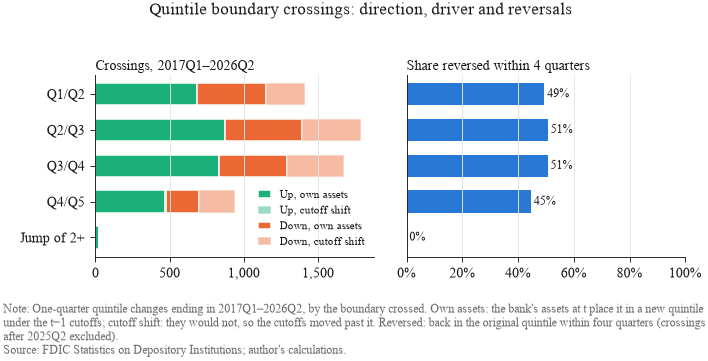

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(WIDTH, 2.6), sharey=True)
y = np.arange(len(BOUNDARIES))[::-1]

# Left: direction of crossings, split by driver
up_own = cross.loc[(cross["status"] == "Moved up") & (cross["driver"] == "Own asset change")].groupby("boundary").size()
up_cut = cross.loc[(cross["status"] == "Moved up") & (cross["driver"] == "Cutoff shift")].groupby("boundary").size()
dn_own = cross.loc[(cross["status"] == "Moved down") & (cross["driver"] == "Own asset change")].groupby("boundary").size()
dn_cut = cross.loc[(cross["status"] == "Moved down") & (cross["driver"] == "Cutoff shift")].groupby("boundary").size()
parts = [("Up, own assets", up_own, STATUS_COLORS["Moved up"], 1.0),
         ("Up, cutoff shift", up_cut, STATUS_COLORS["Moved up"], 0.45),
         ("Down, own assets", dn_own, STATUS_COLORS["Moved down"], 1.0),
         ("Down, cutoff shift", dn_cut, STATUS_COLORS["Moved down"], 0.45)]
left = np.zeros(len(BOUNDARIES))
for label, s, color, alpha in parts:
    v = s.reindex(BOUNDARIES).fillna(0).to_numpy()
    if v.sum() == 0:  # no bank moves up because the cutoffs fell past it
        continue
    axes[0].barh(y, v, left=left, height=0.62, color=color, alpha=alpha, label=label, edgecolor="white", lw=1)
    left += v
axes[0].set_yticks(y, BOUNDARIES)
axes[0].set_title("Crossings, 2017Q1\u20132026Q2", loc="left", fontsize=9, pad=3)
axes[0].xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:,.0f}"))
axes[0].grid(True, axis="x")
axes[0].grid(False, axis="y")
axes[0].legend(loc="lower right", fontsize=7, ncols=1, handlelength=1.2)

# Right: share reversed within four quarters
r = summary_cross["reversed within 4q"].reindex(BOUNDARIES).to_numpy()
axes[1].barh(y, r, height=0.62, color=STATUS_COLORS["Same quintile"])
for yi, v in zip(y, r):
    axes[1].text(v + 0.01, yi, f"{v:.0%}", va="center", fontsize=8, color=INK)
axes[1].set_xlim(0, 1)
axes[1].xaxis.set_major_formatter(pct0)
axes[1].set_title("Share reversed within 4 quarters", loc="left", fontsize=9, pad=3)
axes[1].grid(True, axis="x")
axes[1].grid(False, axis="y")
axes[1].tick_params(axis="y", length=0)

fig.suptitle("Quintile boundary crossings: direction, driver and reversals", fontsize=11, y=1.03, gid="title")
fig.tight_layout(w_pad=1.5)
add_note(fig, "Note: One-quarter quintile changes ending in 2017Q1\u20132026Q2, by the boundary crossed. Own assets: "
              "the bank's assets at t place it in a new quintile under the t\u22121 cutoffs; cutoff shift: they would "
              "not, so the cutoffs moved past it. Reversed: back in the original quintile within four quarters "
              "(crossings after 2025Q2 excluded)." + SOURCE)
save(fig, "boundary_crossings")
plt.show()

## Year-by-year mobility table

For each calendar year, banks filing at the end of the previous year (Q4) are followed to Q4 of that year (2026: to Q2). The table reports the share that ended the year in a different quintile or exited, and the share that changed quintile at least once during the year.

In [14]:
rows = []
for year in range(START.year, END.year + 1):
    d0 = pd.Timestamp(f"{year - 1}-12-31")
    d1 = min(pd.Timestamp(f"{year}-12-31"), END)
    sub = cur.loc[cur["date"].between(d0, d1)].pivot(index="CERT", columns="date", values="quintile")
    sub = sub.loc[sub[d0].notna()]
    start_q, end_q = sub[d0], sub[d1]
    ever = (sub.iloc[:, 1:].ne(start_q, axis=0) & sub.iloc[:, 1:].notna()).any(axis=1)
    rows.append({"Year": f"{year}" + ("*" if d1 == END and END.month != 12 else ""),
                 "Banks": len(sub),
                 "Up": (end_q > start_q).mean(), "Down": (end_q < start_q).mean(), "Exited": end_q.isna().mean(),
                 "Ever changed": ever.mean()})
mobility = pd.DataFrame(rows).set_index("Year")
mobility.to_csv(TABLES / "quintile_mobility_by_year.csv")

p = lambda v: f"{v * 100:.1f}"
lines = [rf"{y} & {r.Banks:,} & {p(r.Up)} & {p(r.Down)} & {p(r.Exited)} & {p(r['Ever changed'])} \\"
         .replace(",", "{,}") for y, r in mobility.iterrows()]
tex = (r"\begin{tabular}{@{}lrrrrr@{}}" "\n" r"\toprule" "\n"
       r" & & \multicolumn{3}{c}{End of year vs.\ start (\%)} & \\" "\n" r"\cmidrule(lr){3-5}" "\n"
       r"Year & Banks & Up & Down & Exited & Ever changed (\%) \\" "\n" r"\midrule" "\n"
       + "\n".join(lines) + "\n" r"\bottomrule" "\n" r"\end{tabular}" "\n")
(TABLES / "quintile_mobility_by_year.tex").write_text(tex, encoding="utf-8")

# Pooled one-quarter matrix, same format
cells = lambda r: " & ".join(p(v) for v in r)
mlines = [rf"Q{q} & {cells(m1.loc[q])} & " + f"{c1.loc[q].sum():,}".replace(",", "{,}") + r" \\" for q in QUINTILES]
tex_m = (r"\begin{tabular}{@{}lrrrrrrr@{}}" "\n" r"\toprule" "\n"
         r" & \multicolumn{6}{c}{Quintile at $t$ (\%)} & \\" "\n" r"\cmidrule(lr){2-7}" "\n"
         r"Quintile at $t-1$ & Q1 & Q2 & Q3 & Q4 & Q5 & Exit & Bank-quarters \\" "\n" r"\midrule" "\n"
         + "\n".join(mlines) + "\n" r"\bottomrule" "\n" r"\end{tabular}" "\n")
(TABLES / "quintile_transition_matrix.tex").write_text(tex_m, encoding="utf-8")
c1.assign(total=c1.sum(axis=1)).to_csv(TABLES / "quintile_transition_matrix.csv")
print("wrote output/tables/quintile_mobility_by_year.{csv,tex} and quintile_transition_matrix.{csv,tex}")
mobility.style.format({"Banks": "{:,}", "Up": "{:.1%}", "Down": "{:.1%}", "Exited": "{:.1%}", "Ever changed": "{:.1%}"})

wrote output/tables/quintile_mobility_by_year.{csv,tex} and quintile_transition_matrix.{csv,tex}


,Banks,Up,Down,Exited,Ever changed
Year,,,,,
2017,"5,913",2.9%,2.8%,4.2%,8.4%
2018,"5,670",2.5%,2.8%,4.8%,8.0%
2019,"5,406",3.1%,2.9%,4.5%,8.4%
2020,"5,177",3.9%,4.4%,3.5%,10.9%
2021,"5,002",2.9%,3.2%,3.5%,8.7%
2022,"4,839",4.2%,3.3%,3.1%,9.8%
2023,"4,706",3.0%,3.4%,2.7%,8.6%
2024,"4,587",2.4%,3.1%,2.3%,8.0%
2025,"4,487",2.7%,2.7%,3.4%,7.8%


## Findings

Numbers refer to 2017Q1–2026Q2 unless noted.

- **Quarter to quarter, membership is very stable.** 96.0% of banks are in the same quintile one quarter later. About 1.5% move up, 1.6% move down and 0.9% exit. Movement was higher in 1992–2016, mainly because of more upward moves (2.3% a quarter). Jumps of two or more quintiles are rare (28 of 5,848 crossings); jumps that large most likely reflect acquisitions.
- **Over a decade, it is not.** Of the 5,856 banks filing in 2017Q1, 29% had exited by 2026Q2. Among the survivors, 70% were in the same quintile as in 2017, 17% were lower and 13% were higher. Exit rates are similar across quintiles (27–34%) and highest in Q1. Q1 and Q5 are the most persistent groups because each has only one boundary to cross.
- **Movement is concentrated at the boundaries and is often temporary.** 36% of banks changed quintile at least once in the window, but about half of all crossings reversed within four quarters. Banks near a cutoff flip back and forth without a lasting change in size.
- **Most crossings come from the bank's own asset change** (78%). The rest occur because the cutoffs rose past a bank that did not grow, as small banks exit and nominal assets grow. These cutoff-driven crossings are all downward.
- **2020 stands out.** Both up and down moves spiked in 2020Q2, when deposit inflows expanded balance sheets unevenly across banks.

**Implication for the distributional analysis.** Ranking on assets at *t*−1 keeps the groups nearly fixed from one quarter to the next, so quarter-*t* distributions are not driven by composition changes. Across the full window, however, a given quintile holds a substantially different set of banks, and about half of boundary crossings are short-lived noise. A robustness check could assign quintiles on a smoothed size measure (for example, four-quarter average assets) or hold membership fixed for a year.